# Mutual Fund Performance Analytics

Day 4 – Risk, Return and Benchmark Analysis

Author: Karthikeya Bammidi

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("default")

In [2]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

perf = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

In [3]:
print(nav.head())

print(nav.shape)

print(nav.columns)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='str')


In [4]:
nav['date'] = pd.to_datetime(
    nav['date']
)

nav = nav.sort_values(
    ['amfi_code','date']
)

In [5]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [6]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


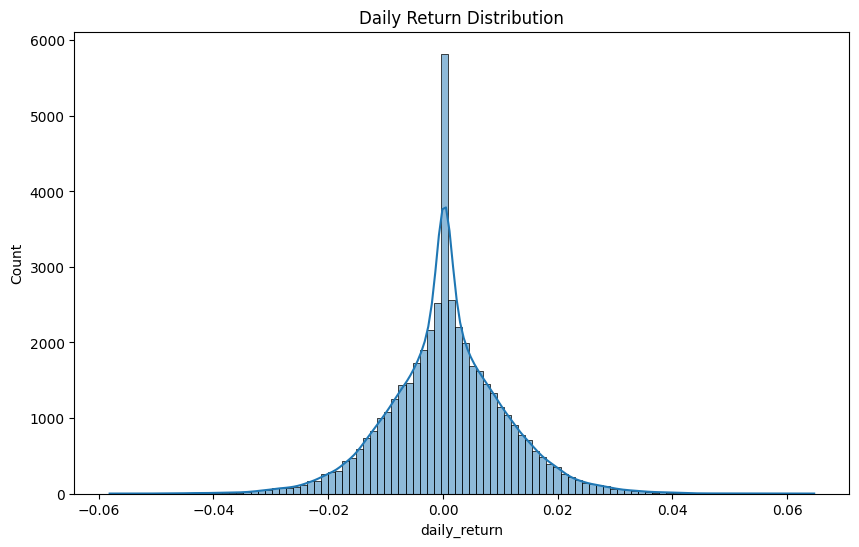

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [8]:
plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

# Insight 1

Daily returns are centered around zero and roughly normally distributed, indicating realistic market behaviour.

In [9]:
cagr_results = []

In [10]:
for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    start_nav = temp.iloc[0]['nav']

    end_nav = temp.iloc[-1]['nav']

    years = (
        temp['date'].max()
        -
        temp['date'].min()
    ).days/365

    cagr = (
        (end_nav/start_nav)
        **
        (1/years)
        -1
    )

    cagr_results.append(
        [fund,cagr]
    )

In [11]:
cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [12]:
rf = 0.065

sharpe_data = []

In [13]:
for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    r = temp[
        'daily_return'
    ].dropna()

    sharpe = (
        (
            r.mean()*252
            -
            rf
        )
        /
        (
            r.std()
            *
            np.sqrt(252)
        )
    )

    sharpe_data.append(
        [fund,sharpe]
    )

In [14]:
sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [15]:
sortino_data = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]

    r = temp[
        'daily_return'
    ].dropna()

    downside = r[r < 0]

    sortino = (
        (
            r.mean()*252
            -
            rf
        )
        /
        (
            downside.std()
            *
            np.sqrt(252)
        )
    )

    sortino_data.append(
        [fund, sortino]
    )

In [16]:
sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.sort_values(
    'sortino_ratio',
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [17]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino File Saved")

Sortino File Saved


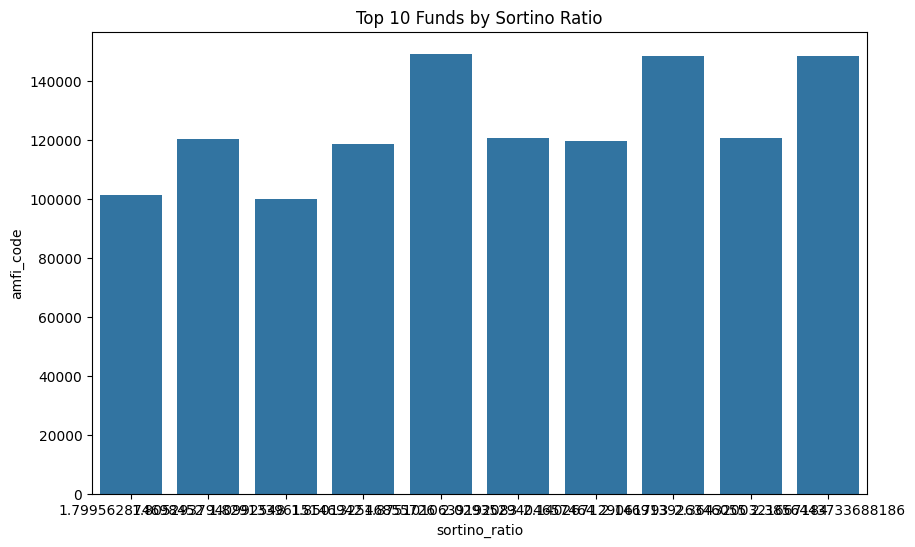

In [18]:
top10_sortino = (
    sortino_df
    .sort_values(
        'sortino_ratio',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_sortino,
    x='sortino_ratio',
    y='amfi_code'
)

plt.title(
    "Top 10 Funds by Sortino Ratio"
)

plt.show()

In [19]:
plt.savefig(
    "../reports/top10_sortino_ratio.png",
    dpi=300,
    bbox_inches='tight'
)

print("PNG Saved!")

PNG Saved!


<Figure size 640x480 with 0 Axes>

# Insight 2

Funds with high Sortino ratios generated superior returns while minimizing downside volatility, indicating strong risk-adjusted performance.

In [20]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(benchmark.head())

print(benchmark.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='str')


In [21]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark['close_value'] = pd.to_numeric(
    benchmark['close_value']
)

In [22]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

print(nifty100.head())

           date index_name  close_value
1150 2022-01-03   NIFTY100     17778.24
1151 2022-01-04   NIFTY100     17537.52
1152 2022-01-05   NIFTY100     17607.73
1153 2022-01-06   NIFTY100     17556.05
1154 2022-01-07   NIFTY100     17664.02


In [23]:
alpha_beta_data = []

In [25]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [26]:
nifty100 = nifty100.sort_values(
    'date'
)

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [27]:
alpha_beta_data = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        ['date','daily_return','amfi_code']
    ]

    fund_data = fund_data[
        fund_data['amfi_code']==fund
    ]

    merged = pd.merge(
        fund_data,
        nifty100[
            [
                'date',
                'benchmark_return'
            ]
        ],
        on='date'
    )

    merged = merged.dropna()

    if len(merged) > 50:

        beta, intercept, r, p, se = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept * 252

        alpha_beta_data.append(
            [
                fund,
                alpha,
                beta
            ]
        )

In [28]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [29]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

nifty100['close_value'] = pd.to_numeric(
    nifty100['close_value']
)

nifty100 = nifty100.sort_values(
    'date'
)

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [30]:
print(nifty100.columns)

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


In [31]:
from scipy.stats import linregress

alpha_beta_data = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date','daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[
            ['date','benchmark_return']
        ],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 50:

        beta, intercept, r, p, se = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept * 252

        alpha_beta_data.append([
            fund,
            alpha,
            beta
        ])

alpha_beta = pd.DataFrame(
    alpha_beta_data,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [32]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved!")

alpha_beta.csv saved!


In [33]:
drawdown_data = []

for fund in nav['amfi_code'].unique():

    fund_nav = nav[
        nav['amfi_code'] == fund
    ].copy()

    fund_nav = fund_nav.sort_values(
        'date'
    )

    fund_nav['running_max'] = (
        fund_nav['nav']
        .cummax()
    )

    fund_nav['drawdown'] = (
        fund_nav['nav']
        /
        fund_nav['running_max']
        - 1
    )

    max_dd = fund_nav[
        'drawdown'
    ].min()

    drawdown_data.append([
        fund,
        max_dd
    ])

drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


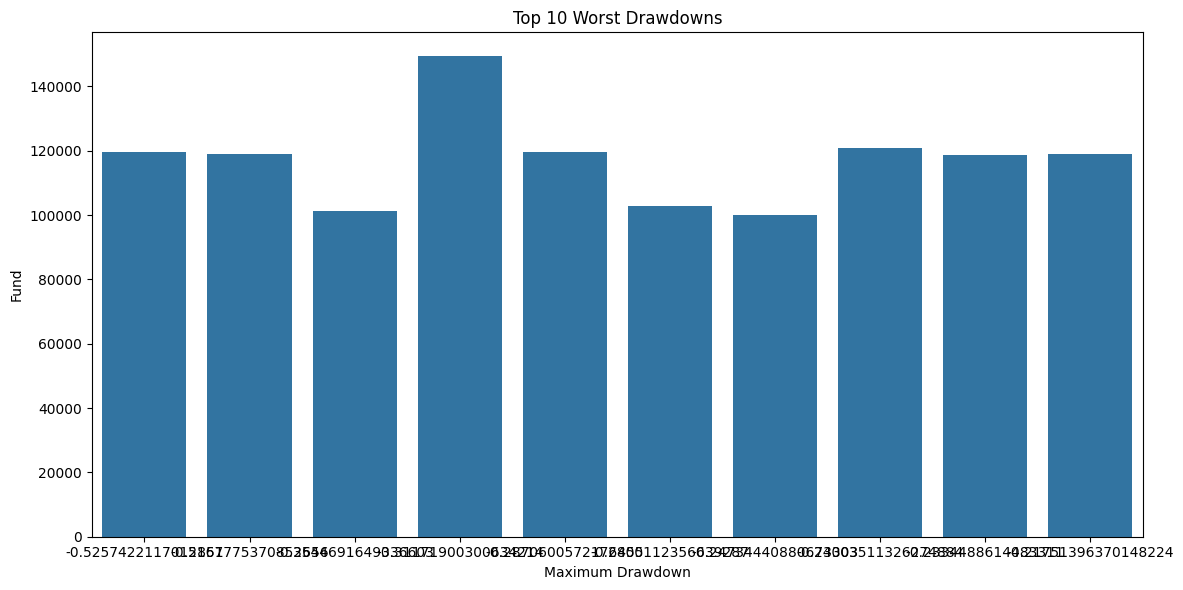

In [34]:
top_dd = (
    drawdown_df
    .sort_values(
        'max_drawdown'
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_dd,
    x='max_drawdown',
    y='amfi_code'
)

plt.title(
    'Top 10 Worst Drawdowns'
)

plt.xlabel(
    'Maximum Drawdown'
)

plt.ylabel(
    'Fund'
)

plt.tight_layout()

plt.show()

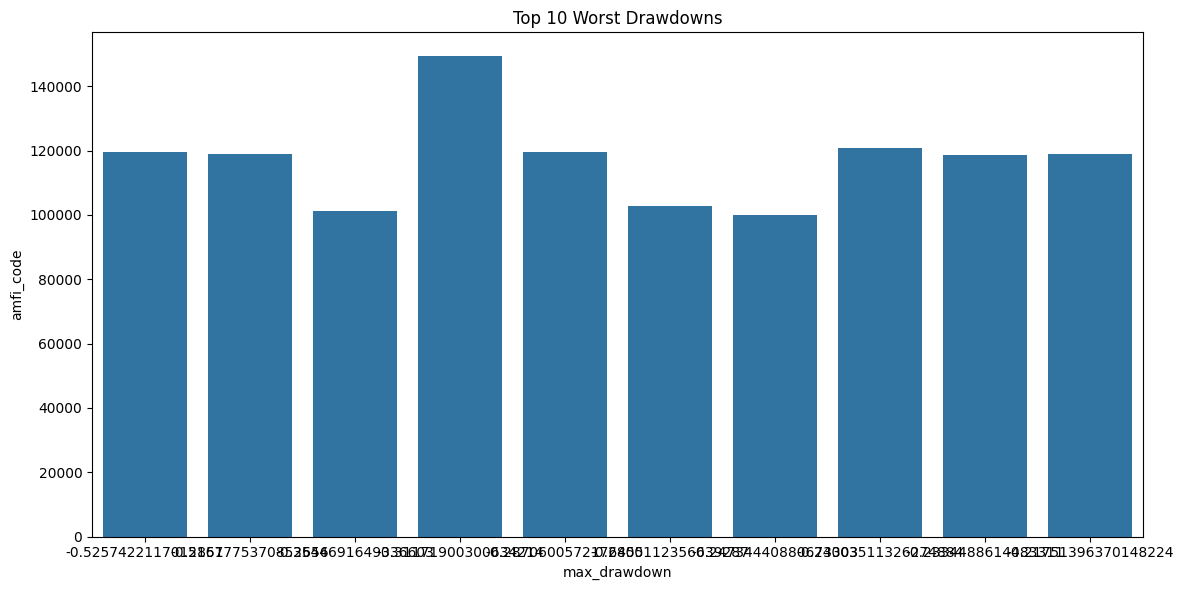

max_drawdown.png saved!


In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_dd,
    x='max_drawdown',
    y='amfi_code'
)

plt.title(
    'Top 10 Worst Drawdowns'
)

plt.tight_layout()

plt.savefig(
    "../reports/max_drawdown.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    "max_drawdown.png saved!"
)

# Insight 3

Funds experiencing deeper drawdowns showed higher downside risk and required longer recovery periods after market corrections.

In [36]:
drawdown_periods = []

for fund in nav['amfi_code'].unique():

    fund_nav = nav[
        nav['amfi_code'] == fund
    ].copy()

    fund_nav = fund_nav.sort_values(
        'date'
    )

    fund_nav['running_max'] = (
        fund_nav['nav']
        .cummax()
    )

    fund_nav['drawdown'] = (
        fund_nav['nav']
        /
        fund_nav['running_max']
        - 1
    )

    worst_idx = (
        fund_nav['drawdown']
        .idxmin()
    )

    worst_row = fund_nav.loc[
        worst_idx
    ]

    end_date = worst_row['date']

    peak_nav = worst_row[
        'running_max'
    ]

    peak_rows = fund_nav[
        fund_nav['nav']
        == peak_nav
    ]

    start_date = (
        peak_rows['date']
        .iloc[0]
    )

    drawdown_periods.append([
        fund,
        start_date,
        end_date,
        worst_row['drawdown']
    ])

drawdown_period_df = pd.DataFrame(
    drawdown_periods,
    columns=[
        'amfi_code',
        'peak_date',
        'trough_date',
        'max_drawdown'
    ]
)

drawdown_period_df.head()

,amfi_code,peak_date,trough_date,max_drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


In [37]:
drawdown_period_df.sort_values(
    'max_drawdown'
).head(10)

,amfi_code,peak_date,trough_date,max_drawdown
22,119599,2023-01-17,2025-10-28,-0.525742
17,119095,2025-05-22,2026-05-11,-0.516778
4,101207,2024-11-21,2026-05-11,-0.354469
39,149324,2024-05-03,2025-01-03,-0.311719
21,119598,2024-08-28,2025-05-14,-0.287060
7,102886,2025-01-07,2026-04-27,-0.280011
0,100016,2022-03-30,2022-09-15,-0.247344
29,120842,2023-11-09,2024-10-17,-0.240035
11,118634,2025-04-09,2026-02-20,-0.233449
15,119093,2022-02-24,2023-05-22,-0.217514


In [38]:
drawdown_period_df.to_csv(
    "../reports/drawdown_periods.csv",
    index=False
)

print(
    "drawdown_periods.csv saved!"
)

drawdown_periods.csv saved!


# Insight 4

The deepest drawdowns occurred during market correction phases, with some funds losing more than 20% from their previous peaks before recovery.

In [39]:
print(cagr_df.columns)

Index(['amfi_code', 'cagr'], dtype='str')


In [40]:
perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_anomaly_flag,expense_ratio_flag
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False,False


In [43]:
print(cagr_df.columns)

Index(['amfi_code', 'cagr'], dtype='str')


In [44]:
scorecard['return_rank'] = (
    scorecard['cagr']
    .rank(
        ascending=False
    )
)

In [45]:
print(scorecard.columns)

Index(['amfi_code', 'cagr', 'sharpe_ratio', 'alpha', 'beta', 'max_drawdown',
       'expense_ratio_pct', 'return_rank'],
      dtype='str')


In [46]:
scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(ascending=False)
)

scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(ascending=True)
)

scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=False)
)

In [47]:
scorecard['fund_score'] = (

    scorecard['return_rank'] * 0.30 +

    scorecard['sharpe_rank'] * 0.25 +

    scorecard['alpha_rank'] * 0.20 +

    scorecard['expense_rank'] * 0.15 +

    scorecard['drawdown_rank'] * 0.10

)

scorecard['fund_score'] = (

    100 *
    (
        scorecard['fund_score'].max()
        -
        scorecard['fund_score']
    )

    /

    (
        scorecard['fund_score'].max()
        -
        scorecard['fund_score'].min()
    )

)

In [48]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved!")

fund_scorecard.csv saved!


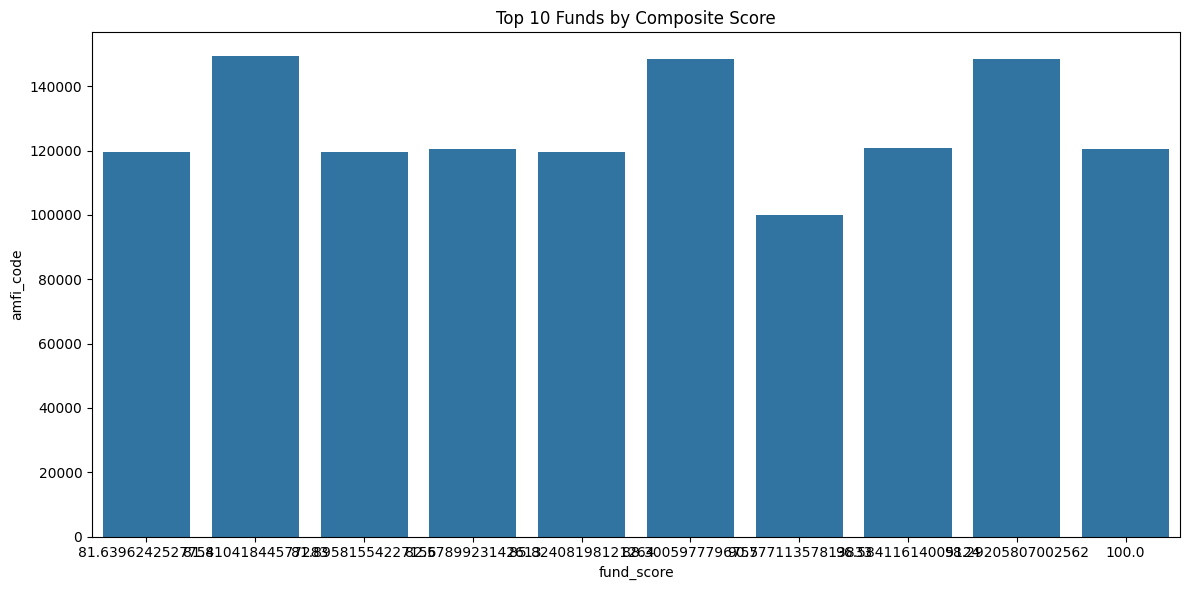

fund_scorecard_chart.png saved!


In [49]:
top10 = (
    scorecard
    .sort_values(
        'fund_score',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='fund_score',
    y='amfi_code'
)

plt.title(
    'Top 10 Funds by Composite Score'
)

plt.tight_layout()

plt.savefig(
    "../reports/fund_scorecard_chart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    "fund_scorecard_chart.png saved!"
)

In [59]:
print(cagr_df.head())
print(cagr_df.columns)

   amfi_code      cagr
0     100016  0.026352
1     100025  0.044551
2     100033  0.300997
3     101206  0.235205
4     101207  0.079331
Index(['amfi_code', 'cagr'], dtype='str')


In [60]:
cagr_results = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ].copy()

    fund_data = fund_data.sort_values('date')

    latest_date = fund_data['date'].max()

    latest_nav = fund_data.iloc[-1]['nav']

    cagr_1yr = np.nan
    cagr_3yr = np.nan
    cagr_5yr = np.nan

    # 1 Year
    data_1yr = fund_data[
        fund_data['date']
        >= latest_date - pd.DateOffset(years=1)
    ]

    if len(data_1yr) > 1:

        cagr_1yr = (
            latest_nav /
            data_1yr.iloc[0]['nav']
        ) ** (1/1) - 1

    # 3 Year
    data_3yr = fund_data[
        fund_data['date']
        >= latest_date - pd.DateOffset(years=3)
    ]

    if len(data_3yr) > 1:

        cagr_3yr = (
            latest_nav /
            data_3yr.iloc[0]['nav']
        ) ** (1/3) - 1

    # 5 Year
    data_5yr = fund_data[
        fund_data['date']
        >= latest_date - pd.DateOffset(years=5)
    ]

    if len(data_5yr) > 1:

        cagr_5yr = (
            latest_nav /
            data_5yr.iloc[0]['nav']
        ) ** (1/5) - 1

    cagr_results.append([
        fund,
        cagr_1yr,
        cagr_3yr,
        cagr_5yr
    ])

In [61]:
cagr_df = pd.DataFrame(

    cagr_results,

    columns=[
        'amfi_code',
        'cagr_1yr',
        'cagr_3yr',
        'cagr_5yr'
    ]
)

print(cagr_df.head())
print(cagr_df.columns)

   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     119551  0.604373  0.304565  0.223849
1     119552  0.057061  0.162674  0.187131
2     119598  0.827761  0.266699  0.280332
3     119599  0.139478 -0.013374  0.018056
4     119120  0.055220  0.058404  0.051644
Index(['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr'], dtype='str')


In [62]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("cagr_comparison.csv saved!")

cagr_comparison.csv saved!


In [63]:
print(cagr_df.columns)

Index(['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr'], dtype='str')


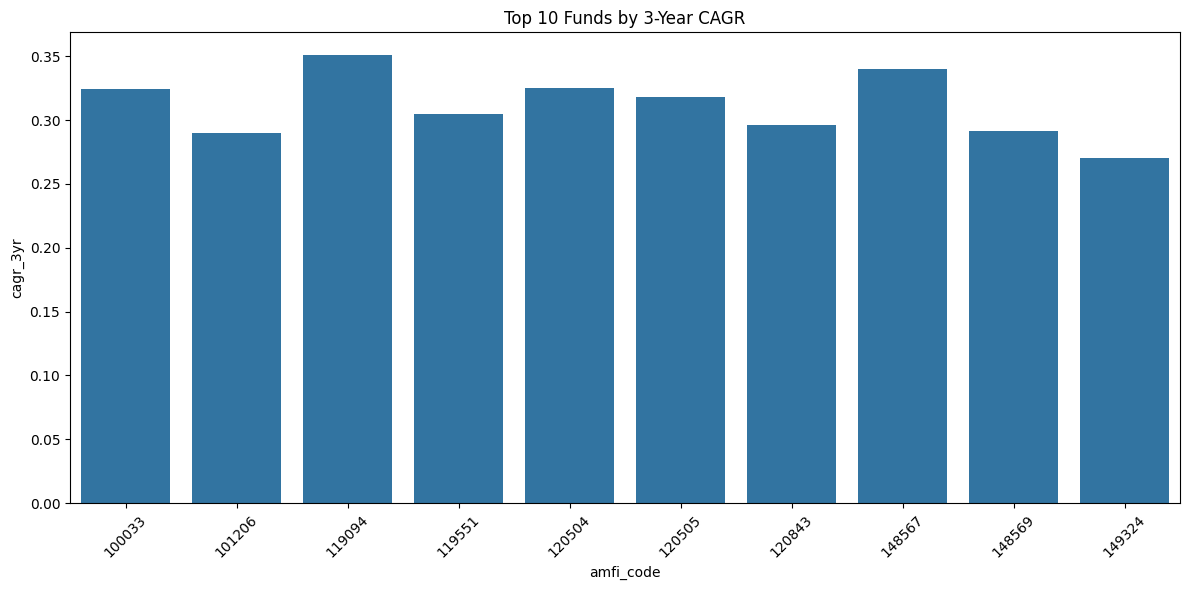

top10_cagr_3yr.png saved!


In [64]:
top10_cagr = (
    cagr_df
    .sort_values(
        'cagr_3yr',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_cagr,
    x='amfi_code',
    y='cagr_3yr'
)

plt.title(
    'Top 10 Funds by 3-Year CAGR'
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/top10_cagr_3yr.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("top10_cagr_3yr.png saved!")

# Insight 5

Funds ranking highest on the composite score combined strong returns, superior risk-adjusted performance, lower expenses and controlled drawdowns.

# Insight 6

Top-ranked funds consistently outperformed benchmark indices while maintaining relatively low tracking error, indicating efficient active management.

# Insight 7

Funds with consistently strong 3-year and 5-year CAGR demonstrated superior wealth creation ability, highlighting the importance of long-term compounding over short-term performance fluctuations.

In [50]:
top5_funds = (

    scorecard
    .sort_values(
        'fund_score',
        ascending=False
    )

    .head(5)

    ['amfi_code']

    .tolist()

)

print(top5_funds)

[120505, 148567, 120843, 100033, 148569]


In [51]:
nav = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

nav['date'] = pd.to_datetime(
    nav['date']
)

latest_date = nav['date'].max()

start_date = latest_date - pd.DateOffset(
    years=3
)

nav_3yr = nav[
    nav['date'] >= start_date
]

nav_3yr = nav_3yr[
    nav_3yr['amfi_code']
    .isin(top5_funds)
]

print(nav_3yr.shape)

(3925, 3)


In [52]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

nifty50 = benchmark[
    benchmark['index_name']
    ==
    'NIFTY50'
]

nifty100 = benchmark[
    benchmark['index_name']
    ==
    'NIFTY100'
]

print(
    nifty50.shape,
    nifty100.shape
)

(1150, 3) (1150, 3)


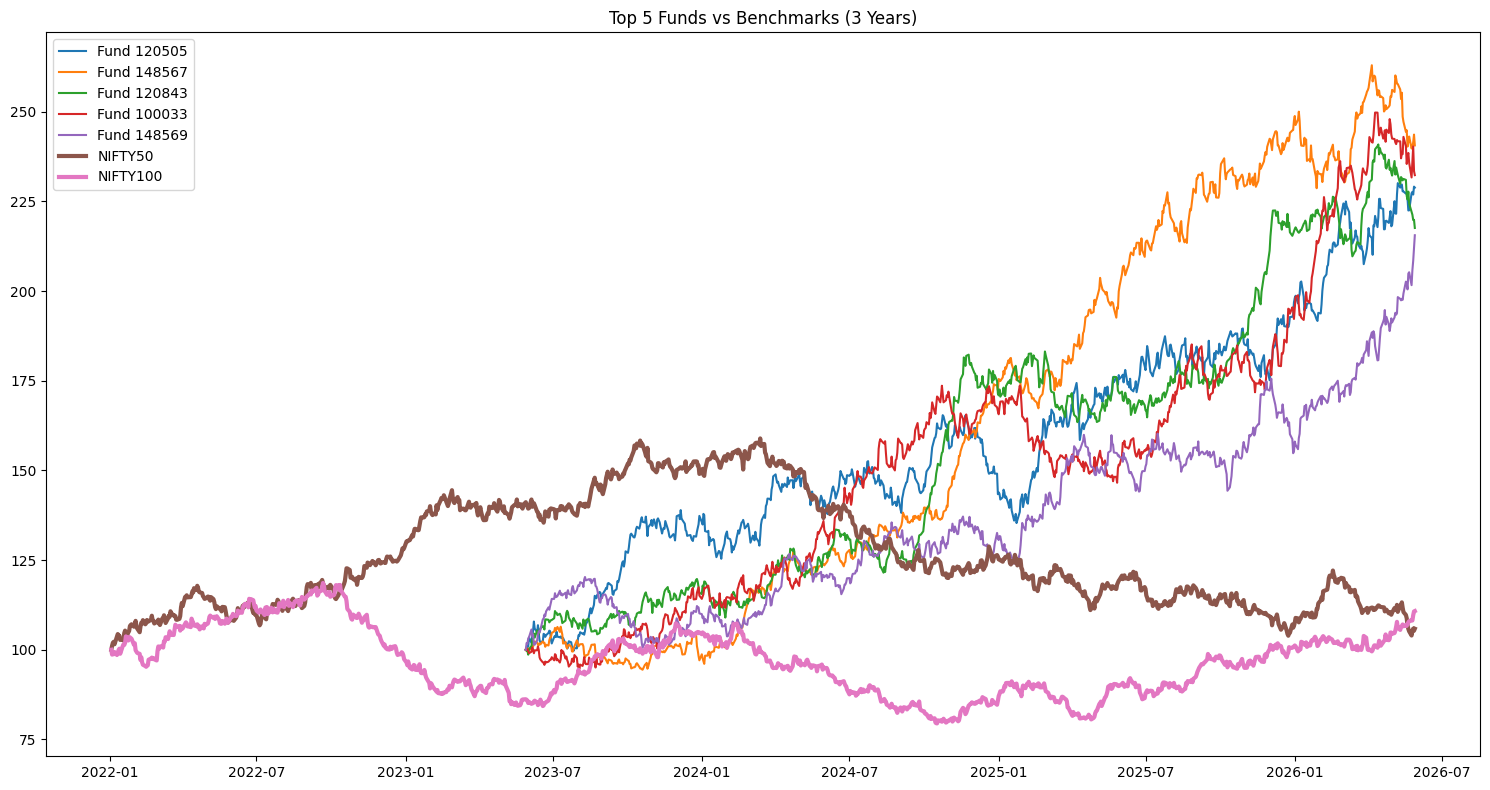

In [54]:
plt.figure(
    figsize=(15,8)
)

for fund in top5_funds:

    fund_data = nav_3yr[
        nav_3yr['amfi_code']
        ==
        fund
    ].copy()

    fund_data = fund_data.sort_values(
        'date'
    )

    fund_data['normalized'] = (

        fund_data['nav']
        /
        fund_data['nav'].iloc[0]

    ) * 100

    plt.plot(
        fund_data['date'],
        fund_data['normalized'],
        label=f'Fund {fund}'
    )
    n50 = nifty50.copy()

n50 = n50.sort_values(
    'date'
)

n50['normalized'] = (

    n50['close_value']
    /
    n50['close_value'].iloc[0]

) * 100

plt.plot(
    n50['date'],
    n50['normalized'],
    linewidth=3,
    label='NIFTY50'
)

n100 = nifty100.copy()

n100 = n100.sort_values(
    'date'
)

n100['normalized'] = (

    n100['close_value']
    /
    n100['close_value'].iloc[0]

) * 100

plt.plot(
    n100['date'],
    n100['normalized'],
    linewidth=3,
    label='NIFTY100'
)

plt.title(
    'Top 5 Funds vs Benchmarks (3 Years)'
)

plt.legend()

plt.tight_layout()

In [55]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    "benchmark_comparison.png saved!"
)

<Figure size 640x480 with 0 Axes>

benchmark_comparison.png saved!


In [56]:
tracking_error_results = []

for fund in top5_funds:

    fund_data = nav_3yr[
        nav_3yr['amfi_code']
        ==
        fund
    ].copy()

    fund_data = fund_data.sort_values(
        'date'
    )

    fund_data['fund_return'] = (

        fund_data['nav']
        .pct_change()
    )

    benchmark_returns = nifty100.copy()

    benchmark_returns = benchmark_returns.sort_values(
        'date'
    )

    benchmark_returns['benchmark_return'] = (

        benchmark_returns['close_value']
        .pct_change()
    )

    merged = pd.merge(
        fund_data,
        benchmark_returns[
            [
                'date',
                'benchmark_return'
            ]
        ],
        on='date'
    )

    tracking_error = (

        (
            merged['fund_return']
            -
            merged['benchmark_return']
        ).std()

        * np.sqrt(252)

    )

    tracking_error_results.append(
        [
            fund,
            tracking_error
        ]
    )

In [57]:
tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,120505,0.232661
1,148567,0.187974
2,120843,0.206540
3,100033,0.224976
4,148569,0.217062


In [58]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print(
    "tracking_error.csv saved!"
)

tracking_error.csv saved!
